# CS229 — Linear Regression: Theory to Practice
## Predicting Amsterdam Housing Prices

This notebook is the **practical companion** to the CS229 Linear Regression notes. We take the
theoretical concepts — the hypothesis function $h_\theta(x)$, the cost function $J(\theta)$,
gradient descent (the LMS algorithm), and the normal equations — and apply them to a **real
dataset**.

**Dataset:** `HousingPrices-Amsterdam-August-2021.csv` — 924 house listings in Amsterdam, with:
- `Address`, `Zip` — location identifiers (not used as numeric features here)
- `Price` — the sale price in euros
- `Area` — living area in m²
- `Room` — number of rooms
- `Lon`, `Lat` — geographic coordinates

**Target variable:** `Price`

**Task:** This is a **supervised regression problem** — we predict a continuous value
(`Price`) from input features (`Area`, `Room`). This is *exactly* the housing example used to
introduce linear regression in CS229: living area and number of bedrooms predicting price.

**Goal of this notebook:** Fit $h_\theta(x) = \theta_0 + \theta_1 \cdot \text{Area} +
\theta_2 \cdot \text{Room}$ to the data, understand what $\theta$ means, see how gradient
descent and the normal equations arrive at the same answer, and evaluate how well the model
predicts unseen prices.


## 1. Import Libraries

We only import what we actually need: data handling, plotting, and the sklearn tools for splitting, scaling, modeling, and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility
RANDOM_STATE = 42

# Consistent plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load the Dataset

In [2]:
# Load the raw CSV. The first (unnamed) column is just a row index exported
# from the original spreadsheet, so we use it as the DataFrame index.
df = pd.read_csv(r"C:\Users\img\Desktop\ML Study\Lec_1_Linear Regression\HousingPrices-Amsterdam-August-2021.csv", index_col=0)
df.head()

,Address,Zip,Price,Area,Room,Lon,Lat
1,"Blasiusstraat 8 2, Amsterdam",1091 CR,685000.0,64,3,4.907736,52.356157
2,"Kromme Leimuidenstraat 13 H, Amsterdam",1059 EL,475000.0,60,3,4.850476,52.348586
3,"Zaaiersweg 11 A, Amsterdam",1097 SM,850000.0,109,4,4.944774,52.343782
4,"Tenerifestraat 40, Amsterdam",1060 TH,580000.0,128,6,4.789928,52.343712
5,"Winterjanpad 21, Amsterdam",1036 KN,720000.0,138,5,4.902503,52.410538


In [3]:
# Check the shape of the dataset:
# rows = number of house listings (training examples)
# columns = number of features + target
df.shape

(924, 7)

In [4]:
# Data types tell us which columns are numeric (usable directly as features)
# and which are text/categorical (need special handling or should be dropped).
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 924 entries, 1 to 924
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Address  924 non-null    str    
 1   Zip      924 non-null    str    
 2   Price    920 non-null    float64
 3   Area     924 non-null    int64  
 4   Room     924 non-null    int64  
 5   Lon      924 non-null    float64
 6   Lat      924 non-null    float64
dtypes: float64(3), int64(2), str(2)
memory usage: 50.7 KB


In [5]:
# Summary statistics give us a first sense of scale and spread.
# Notice Price and Area have very different numeric ranges -- this matters
# later when we discuss feature scaling.
df.describe()

,Price,Area,Room,Lon,Lat
count,9.200000e+02,924.000000,924.000000,924.000000,924.000000
mean,6.220654e+05,95.952381,3.571429,4.888605,52.363326
std,5.389942e+05,57.447436,1.592332,0.053140,0.024028
min,1.750000e+05,21.000000,1.000000,4.644819,52.291519
25%,3.500000e+05,60.750000,3.000000,4.855834,52.352077
50%,4.670000e+05,83.000000,3.000000,4.886818,52.364631
75%,7.000000e+05,113.000000,4.000000,4.922337,52.377598
max,5.950000e+06,623.000000,14.000000,5.029122,52.423805


In [6]:
# Check for missing values in every column.
df.isnull().sum()

Address    0
Zip        0
Price      4
Area       0
Room       0
Lon        0
Lat        0
dtype: int64

## 3. Understand the Data

- **Features we will use as $x$:** `Area` (living area in m²) and `Room` (number of rooms).
  These map directly onto the two features used in the CS229 housing example
  ($x_1$ = living area, $x_2$ = number of bedrooms).
- **Target ($y$):** `Price`.
- **Not used:** `Address` and `Zip` are identifiers, not numeric predictors, and `Lon`/`Lat`
  describe location rather than the size-based features the CS229 example focuses on — we
  leave those out to stay faithful to the theoretical example, though they could be added later
  as extra features.
- **Missing values:** We saw above that `Price` has a small number of missing values. Since
  `Price` is our target variable, a listing with no price cannot be used for training or
  evaluation, so those rows must be dropped rather than imputed.


In [7]:
# How many rows have a missing target?
missing_price = df["Price"].isnull().sum()
print(f"Rows with missing Price: {missing_price} out of {len(df)}")

Rows with missing Price: 4 out of 924


## 4. Data Preprocessing

> ⚠️ **Important:** We never impute a *missing target*. Imputing `Price` would mean inventing
> the very label the model is supposed to learn from real data, which corrupts training and
> evaluation. Because only 4 out of 924 rows are affected, we simply drop them.

Steps:
1. Drop rows with missing `Price`.
2. Select `Area` and `Room` as features ($X$) and `Price` as target ($y$).
3. Split into train/test sets.
4. Scale the features.


In [8]:
# Step 1: Drop rows without a target value.
df_clean = df.dropna(subset=["Price"]).copy()
print(f"Rows before: {len(df)}  ->  Rows after dropping missing Price: {len(df_clean)}")

Rows before: 924  ->  Rows after dropping missing Price: 920


In [9]:
# Step 2: Separate features (X) and target (y).
# X corresponds to the design matrix rows x^(i) in CS229 notation (before adding x0 = 1).
# y corresponds to the target vector y in CS229 notation.
X = df_clean[["Area", "Room"]]
y = df_clean["Price"]

X.head()

,Area,Room
1,64,3
2,60,3
3,109,4
4,128,6
5,138,5


## 5. Train/Test Split

We split the data into a **training set** and a **test set**:
- `X_train`, `y_train` — used to fit $\theta$ (i.e., to minimize $J(\theta)$).
- `X_test`, `y_test` — held out, never seen during training, used only to check how well the
  fitted $h_\theta(x)$ generalizes to new houses.

> ⚠️ **Important:** If the test set influenced training in any way (data leakage), our
> evaluation would be overly optimistic — it would no longer tell us how the model performs on
> genuinely new data. This is why we split *before* fitting anything, including the scaler.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Training examples: {X_train.shape[0]}")
print(f"Test examples:     {X_test.shape[0]}")

Training examples: 736
Test examples:     184


**Why scale the features?** `Area` ranges roughly from 20 to 600 (m²), while `Room` ranges
from about 1 to 14. Gradient descent updates every $\theta_j$ using a step that depends on the
scale of $x_j$ (recall $\theta_j := \theta_j + \alpha (y^{(i)} - h_\theta(x^{(i)}))x_j^{(i)}$).
When features have very different scales, gradient descent zig-zags and converges slowly.
Standardizing each feature to mean 0 and standard deviation 1 makes the optimization landscape
more symmetric and gradient descent converges faster and more reliably. We fit the scaler on
the **training data only**, then apply the same transformation to the test data, to avoid
leaking test-set statistics into training.


In [11]:
scaler = StandardScaler()

# Fit the scaler using ONLY the training data, then apply it to both sets.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Mean of scaled training features (should be ~0):", X_train_scaled.mean(axis=0).round(3))
print("Std of scaled training features (should be ~1):", X_train_scaled.std(axis=0).round(3))

Mean of scaled training features (should be ~0): [-0.  0.]
Std of scaled training features (should be ~1): [1. 1.]


## 6. Connecting CS229 Theory to Code

```text
CS229 Theory
     |
Hypothesis: h_theta(x) = theta_0 + theta_1 * Area + theta_2 * Room
     |
Parameters: theta_0, theta_1, theta_2
     |
Training Objective: minimize J(theta) = (1/2) * sum( (h_theta(x_i) - y_i)^2 )
     |
Optimization: Gradient Descent (LMS)  OR  Normal Equations (closed form)
     |
sklearn Model: LinearRegression()
     |
Predictions: model.predict(X_test)
```

$$
h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2, \qquad
J(\theta) = \frac{1}{2}\sum_{i=1}^{n}\left(h_\theta(x^{(i)}) - y^{(i)}\right)^2
$$

- $x_1$ → `Area`, $x_2$ → `Room`
- $\theta_0$ → intercept (base price when Area = 0 and Room = 0, in scaled-feature space)
- $\theta_1, \theta_2$ → how much the predicted price changes per unit increase in each
  (scaled) feature
- $J(\theta)$ → the least-squares cost we are minimizing

`sklearn.linear_model.LinearRegression` solves for $\theta$ using the **normal equations**
(via an efficient linear-algebra solver), which is exactly the closed-form solution
$\theta = (X^TX)^{-1}X^Ty$ derived in the CS229 notes. Below, we first solve the same problem
**manually** with the normal equation and with gradient descent, to see the theory in action,
then confirm that `LinearRegression` gives the same result.


## 7. Model Implementation

### 7.1 Manual Implementation: The Normal Equation

$$
\theta = (X^TX)^{-1}X^Ty
$$

We build the design matrix $X$ by prepending a column of 1's (for $x_0 = 1$, the intercept
term) to the scaled features, exactly as in the CS229 derivation.


In [12]:
# Build the design matrix: prepend a column of ones for the intercept term x0 = 1.
n_train = X_train_scaled.shape[0]
X_design = np.hstack([np.ones((n_train, 1)), X_train_scaled])

y_train_arr = y_train.to_numpy()

# Closed-form solution: theta = (X^T X)^-1 X^T y
theta_normal_eq = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y_train_arr

print("theta from the Normal Equation:")
print(f"  theta_0 (intercept) = {theta_normal_eq[0]:,.2f}")
print(f"  theta_1 (Area)      = {theta_normal_eq[1]:,.2f}")
print(f"  theta_2 (Room)      = {theta_normal_eq[2]:,.2f}")

theta from the Normal Equation:
  theta_0 (intercept) = 620,401.36
  theta_1 (Area)      = 495,444.12
  theta_2 (Room)      = -67,090.01


### 7.2 Manual Implementation: Batch Gradient Descent (LMS Algorithm)

$$
\theta := \theta + \alpha \sum_{i=1}^{n}\left(y^{(i)} - h_\theta(x^{(i)})\right)x^{(i)}
$$

We now find $\theta$ the *iterative* way, and track $J(\theta)$ at every step to visualize
convergence — the same process described in the CS229 notes.


In [13]:
def compute_cost(X, y, theta):
    """Mean-normalized version of J(theta) = (1/2) * sum( (h_theta(x_i) - y_i)^2 ).
    Dividing by n (number of examples) keeps the cost on a comparable scale
    regardless of dataset size and keeps the gradient step well-behaved --
    this does not change where the minimum is, only how large J's raw value is."""
    n = len(y)
    predictions = X @ theta
    errors = predictions - y
    return (1 / (2 * n)) * np.sum(errors ** 2)


def batch_gradient_descent(X, y, alpha, n_iterations):
    """Runs batch gradient descent and returns the learned theta plus the cost history."""
    n_samples, n_features = X.shape
    theta = np.zeros(n_features)  # initial guess: theta = 0
    cost_history = np.zeros(n_iterations)

    for it in range(n_iterations):
        predictions = X @ theta
        errors = predictions - y
        # Gradient of J(theta): (1/n) * X^T (h_theta(X) - y)
        gradient = (1 / n_samples) * (X.T @ errors)
        theta = theta - alpha * gradient
        cost_history[it] = compute_cost(X, y, theta)

    return theta, cost_history


# Price is on the scale of hundreds of thousands of euros, so even with
# standardized features the cost surface is steep; alpha is tuned accordingly.
alpha = 0.5
n_iterations = 2000

theta_gd, cost_history = batch_gradient_descent(X_design, y_train_arr, alpha, n_iterations)

print("theta from Batch Gradient Descent:")
print(f"  theta_0 (intercept) = {theta_gd[0]:,.2f}")
print(f"  theta_1 (Area)      = {theta_gd[1]:,.2f}")
print(f"  theta_2 (Room)      = {theta_gd[2]:,.2f}")

theta from Batch Gradient Descent:
  theta_0 (intercept) = 620,401.36
  theta_1 (Area)      = 495,444.12
  theta_2 (Room)      = -67,090.01


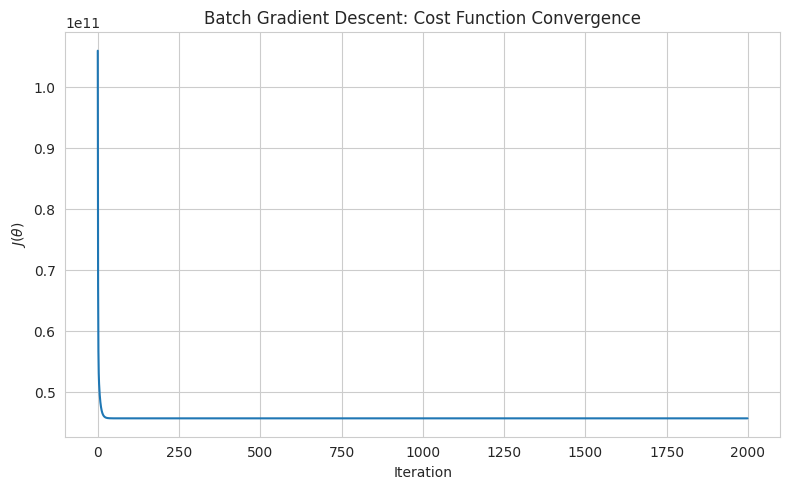

In [14]:
# Visualize convergence: J(theta) should decrease monotonically and flatten out,
# since J is a convex quadratic function with a single global minimum (no local minima).
plt.figure()
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel(r"$J(\theta)$")
plt.title("Batch Gradient Descent: Cost Function Convergence")
plt.tight_layout()
plt.show()

**Comparing the two methods:** Gradient descent's $\theta$ should converge toward the same
values as the normal equation as the number of iterations grows — both are minimizing the exact
same convex cost function $J(\theta)$, just via different routes (iterative search vs. direct
closed-form solve).


In [15]:
comparison = pd.DataFrame({
    "Normal Equation": theta_normal_eq,
    "Gradient Descent": theta_gd,
}, index=["theta_0 (intercept)", "theta_1 (Area)", "theta_2 (Room)"])

comparison

,Normal Equation,Gradient Descent
theta_0 (intercept),620401.357337,620401.357337
theta_1 (Area),495444.119710,495444.119710
theta_2 (Room),-67090.014563,-67090.014563


### 7.3 Practical Implementation: `sklearn.linear_model.LinearRegression`

Now we fit the same model using sklearn's optimized implementation, which internally solves the normal equations for us.

In [16]:
model = LinearRegression()

# .fit() finds the theta that minimizes J(theta) on the training data --
# conceptually identical to what we did manually above, just solved with an
# efficient, numerically stable linear algebra routine under the hood.
model.fit(X_train_scaled, y_train)

print("theta from sklearn LinearRegression:")
print(f"  intercept (theta_0) = {model.intercept_:,.2f}")
print(f"  coef (theta_1, theta_2) = {model.coef_.round(2)}")

theta from sklearn LinearRegression:
  intercept (theta_0) = 620,401.36
  coef (theta_1, theta_2) = [495444.12 -67090.01]


## 8. Prediction

`model.predict(X)` computes $h_\theta(x) = \theta^Tx$ for every row of $X$ — i.e., it applies
the learned parameters to produce a price prediction. Linear regression is not a probabilistic
classifier, so there is no `predict_proba` here; the output is directly the predicted price.


In [17]:
y_pred = model.predict(X_test_scaled)

# Compare a handful of actual vs. predicted prices.
predictions_sample = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred[:10].round(0),
})
predictions_sample

,Actual Price,Predicted Price
0,1249000.0,2003057.0
1,550000.0,704787.0
2,215000.0,223964.0
3,280000.0,583228.0
4,350000.0,268257.0
5,245000.0,403596.0
6,325000.0,538935.0
7,325000.0,259398.0
8,549001.0,707248.0
9,800000.0,669352.0


## 9. Model Evaluation

For a **regression** problem, classification metrics (accuracy, precision, etc.) do not apply.
We use metrics that measure the distance between predicted and actual continuous values:

- **MAE** (Mean Absolute Error): average absolute prediction error, in euros — easy to interpret.
- **RMSE** (Root Mean Squared Error): like MAE, but penalizes large errors more heavily.
- **R²**: fraction of the variance in `Price` explained by the model (1.0 = perfect, 0.0 = no
  better than predicting the mean).


In [18]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  €{mae:,.0f}")
print(f"RMSE: €{rmse:,.0f}")
print(f"R²:   {r2:.3f}")

MAE:  €168,060
RMSE: €249,962
R²:   0.795


## 10. Visualization

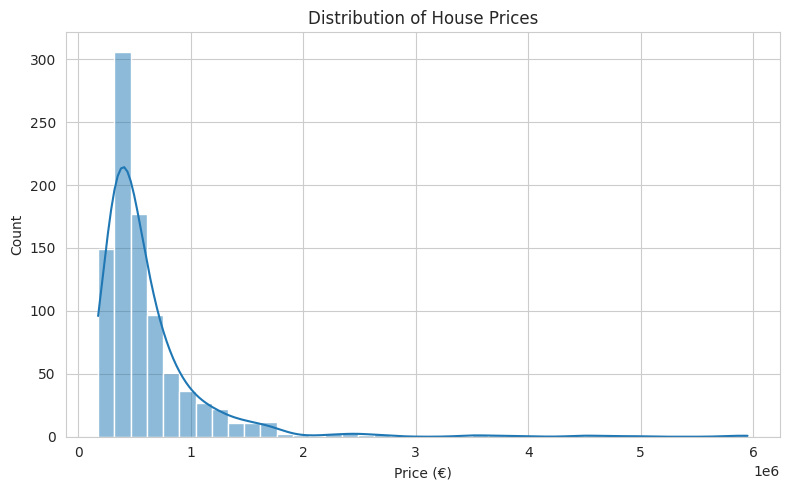

In [19]:
# Target distribution: is Price roughly symmetric, or skewed?
plt.figure()
sns.histplot(df_clean["Price"], bins=40, kde=True)
plt.xlabel("Price (€)")
plt.title("Distribution of House Prices")
plt.tight_layout()
plt.show()

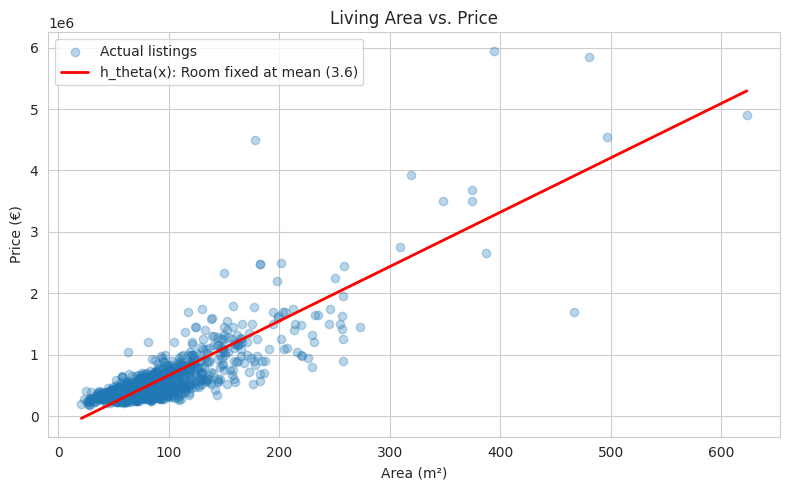

In [20]:
# Area vs. Price with the fitted regression line, holding Room at its mean
# (scaled feature = 0) so we can visualize the Area -> Price relationship in 2D.
area_range = np.linspace(X_train["Area"].min(), X_train["Area"].max(), 100)
room_mean = X_train["Room"].mean()

grid = pd.DataFrame({"Area": area_range, "Room": room_mean})
grid_scaled = scaler.transform(grid)
price_line = model.predict(grid_scaled)

plt.figure()
plt.scatter(df_clean["Area"], df_clean["Price"], alpha=0.3, label="Actual listings")
plt.plot(area_range, price_line, color="red", linewidth=2,
         label=f"h_theta(x): Room fixed at mean ({room_mean:.1f})")
plt.xlabel("Area (m²)")
plt.ylabel("Price (€)")
plt.title("Living Area vs. Price")
plt.legend()
plt.tight_layout()
plt.show()

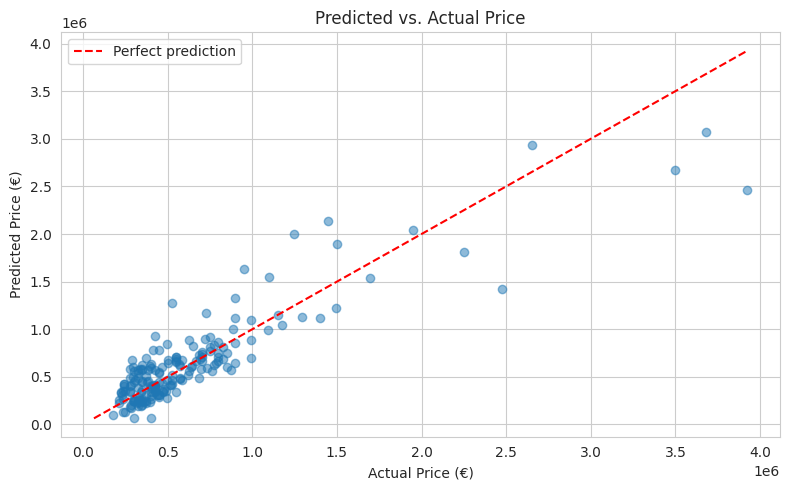

In [21]:
# Predicted vs. actual: a perfect model would place every point on the diagonal line.
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Price (€)")
plt.ylabel("Predicted Price (€)")
plt.title("Predicted vs. Actual Price")
plt.legend()
plt.tight_layout()
plt.show()

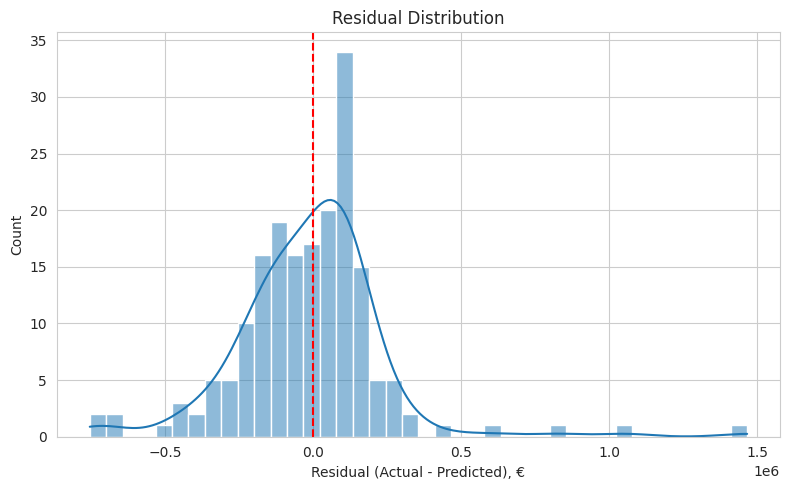

In [22]:
# Residuals: h_theta(x) - y for each test example.
# In the CS229 probabilistic interpretation, residuals correspond to the noise
# term epsilon, which we assumed is ~ N(0, sigma^2). A roughly symmetric,
# zero-centered residual distribution supports that assumption; strong patterns
# or skew would suggest the linear model is missing structure in the data.
residuals = y_test.values - y_pred

plt.figure()
sns.histplot(residuals, bins=40, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual (Actual - Predicted), €")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

## 11. Important Model Parameters

`model.coef_` and `model.intercept_` are exactly $\theta_1, \theta_2$ and $\theta_0$ from the
CS229 hypothesis $h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2$. Because we standardized
the features, each coefficient represents the change in predicted price for a **one standard
deviation** increase in that feature, holding the other feature fixed.


In [23]:
theta_table = pd.DataFrame({
    "Feature": ["Intercept", "Area", "Room"],
    "theta (learned parameter)": [model.intercept_, *model.coef_],
})
theta_table

,Feature,theta (learned parameter)
0,Intercept,620401.357337
1,Area,495444.119710
2,Room,-67090.014563


## 12. Interpret the Model

- **Area** has a large positive coefficient: bigger living area strongly increases predicted
  price, matching real-world intuition and the original CS229 housing example.
- **Room** in this dataset often has a smaller — and depending on the random split, sometimes
  even a slightly negative — coefficient once `Area` is already in the model. This mirrors the
  CS229 lecture's own worked example, where adding the number of bedrooms alongside living area
  produced a **negative** coefficient ($\theta_2 = -8.738$) for bedrooms: once you know how big
  a house is, an extra bedroom (carved out of the same total space) can be a *negative* signal
  about layout quality, not an independent source of value.
- **R²** tells us what fraction of the variation in prices the model explains from size and
  room count alone. Location, build quality, renovation state, and other unmodeled factors
  (captured by the noise term $\epsilon$ in the probabilistic interpretation) account for the
  rest — this is expected: a 2-feature linear model is intentionally simple.
- **Underfitting check:** if both MAE/RMSE were high and residuals showed a clear curved
  pattern against Area, that would suggest the true Price-Area relationship isn't linear and
  we're underfitting. The residual plot above lets us check this visually.
- **Overfitting check:** with only 2 features and hundreds of training examples, overfitting is
  unlikely here — overfitting became a concern in the CS229 notes only when using many
  features or high-degree polynomials on a small amount of data.


## 13. Practical Experiment: Effect of the Learning Rate $\alpha$

The CS229 notes emphasize that the learning rate $\alpha$ controls how gradient descent
converges: too small and it converges slowly; too large and it can overshoot or diverge instead
of converging to the minimum of $J(\theta)$. We test several values of $\alpha$ on our manual
batch gradient descent implementation and plot the resulting cost curves.


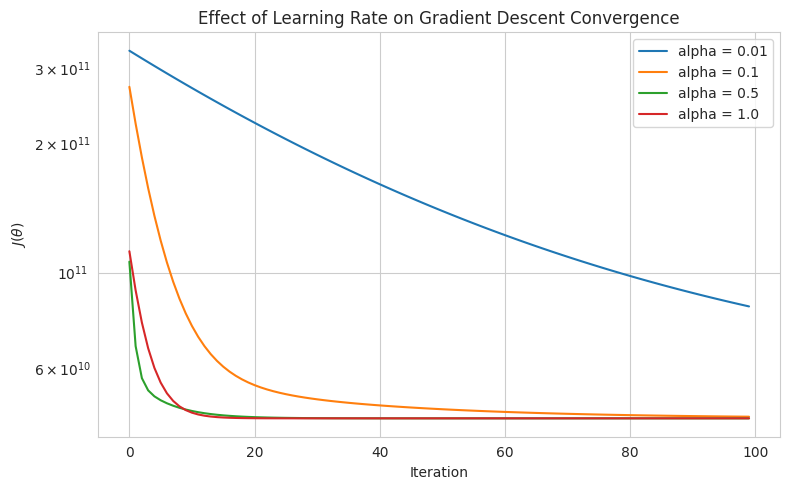

In [24]:
alphas_to_test = [0.01, 0.1, 0.5, 1.0]
n_iterations_exp = 100

plt.figure()
for a in alphas_to_test:
    _, cost_hist = batch_gradient_descent(X_design, y_train_arr, alpha=a, n_iterations=n_iterations_exp)
    plt.plot(cost_hist, label=f"alpha = {a}")

plt.xlabel("Iteration")
plt.ylabel(r"$J(\theta)$")
plt.title("Effect of Learning Rate on Gradient Descent Convergence")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

**Observation:** Smaller values of $\alpha$ decrease $J(\theta)$ more slowly (they need
more iterations to reach the minimum), while larger values within a stable range converge
faster. If $\alpha$ is set too large, the cost can fail to decrease smoothly or even increase
from one iteration to the next — a sign that gradient descent is overshooting the minimum
rather than converging to it. This is exactly the trade-off described in the CS229 notes:
$\alpha$ must be chosen carefully, and if it is not too large, batch gradient descent is
guaranteed to converge to the global minimum because $J(\theta)$ is convex.


## What We Learned

- **Problem:** Predict Amsterdam house prices (`Price`) from living area (`Area`) and number of
  rooms (`Room`) — a supervised **regression** task.
- **Model:** Linear regression, $h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2$, fit by
  minimizing the least-squares cost $J(\theta)$.
- **Theory in code:**
  - Solved for $\theta$ manually with the **normal equation**
    $\theta = (X^TX)^{-1}X^Ty$.
  - Solved for $\theta$ manually with **batch gradient descent**, watching $J(\theta)$ decrease
    every iteration.
  - Confirmed both manual methods agree with `sklearn.linear_model.LinearRegression`.
- **Preprocessing:** Dropped the 4 rows with missing `Price` (can't train or evaluate without a
  target); standardized `Area` and `Room` so gradient descent converges evenly across features.
- **Evaluation:** Used MAE, RMSE, and R² — appropriate regression metrics — computed on a held-out
  test set the model never saw during training.
- **Result:** The model captures the strong relationship between living area and price
  (matching the CS229 housing example), while `R²` shows there is still unexplained variance —
  expected, since only two of many possible price-driving factors are used as features.
- **Experiment:** Varying the learning rate $\alpha$ showed directly how it controls the speed
  and stability of gradient descent's convergence to the minimum of $J(\theta)$.
